# **Project Data Analysis Course**
**Name: M Tazeem Sajid**

**Batch: 302**

# **STEP 1 — Imports Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from google.colab import files
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# **STEP 2 — Load dataset**

In [2]:
uploaded = files.upload()  # Colab upload dialog
filename = next(iter(uploaded.keys()))
print(f"Using file: {filename}")
# Read CSV
df = pd.read_csv(filename)

Saving cryptocurrency.csv to cryptocurrency.csv
Using file: cryptocurrency.csv


# **STEP 3 — EDA like (structure, missing, duplicates) check**

Shape: (93486, 9)

--- Dataframe info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93486 entries, 0 to 93485
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   timestamp   93486 non-null  object
 1   name        93486 non-null  object
 2   symbol      93486 non-null  object
 3   price_usd   93486 non-null  object
 4   vol_24h     93486 non-null  object
 5   total_vol   93486 non-null  object
 6   chg_24h     93486 non-null  object
 7   chg_7d      93470 non-null  object
 8   market_cap  93450 non-null  object
dtypes: object(9)
memory usage: 6.4+ MB
None

--- First 5 rows ---


,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap
0,2025-09-22 01:35:11,Dogecoin,DOGE,0.261902,$1.70B,1.62%,-2.46%,-6.60%,$39.46B
1,2025-09-22 01:35:11,Ethereum,ETH,"4,457.47",$17.18B,17.94%,-0.70%,-3.43%,$538.65B
2,2025-09-22 01:35:11,XRP,XRP,2.9748,$2.94B,2.90%,-0.32%,-2.33%,$177.64B
3,2025-09-22 01:35:11,Bitcoin,BTC,"115,322.10",$21.49B,22.11%,-0.43%,-0.51%,$2.30T
4,2025-09-22 01:35:11,Solana,SOL,236.179,$3.33B,3.19%,-1.66%,-2.29%,$128.17B



--- Missing values per column ---
timestamp      0
name           0
symbol         0
price_usd      0
vol_24h        0
total_vol      0
chg_24h        0
chg_7d        16
market_cap    36
dtype: int64

--- Duplicate rows count ---
0

--- Unique counts for key columns ---
Unique names: 65
Unique symbols: 68


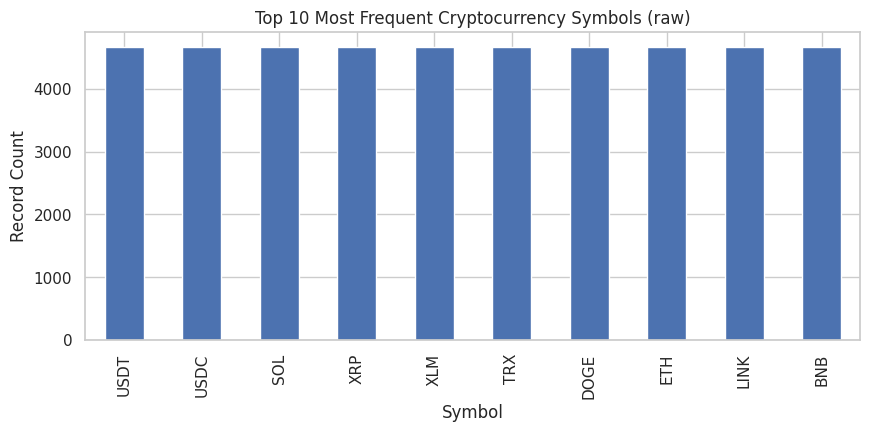

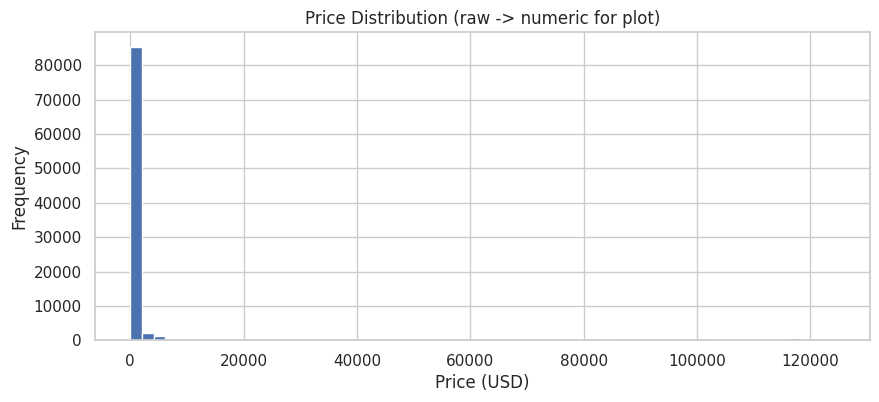

In [4]:
# STEP 3: Initial EDA (raw)
print("Shape:", df.shape)
print("\n--- Dataframe info ---")
print(df.info())

print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Missing values per column ---")
print(df.isnull().sum())

print("\n--- Duplicate rows count ---")
print(df.duplicated().sum())

print("\n--- Unique counts for key columns ---")
print("Unique names:", df['name'].nunique())
print("Unique symbols:", df['symbol'].nunique())


# top 10 most frequent symbols in dataset
plt.figure(figsize=(10,4))
df['symbol'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Frequent Cryptocurrency Symbols (raw)")
plt.xlabel("Symbol")
plt.ylabel("Record Count")
plt.show()

# Histogram of raw price strings converted to numeric
raw_price_numeric = pd.to_numeric(
    df['price_usd'].astype(str).str.replace('[\$,]', '', regex=True),
    errors='coerce'
)
plt.figure(figsize=(10,4))
raw_price_numeric.dropna().hist(bins=60)
plt.title("Price Distribution (raw -> numeric for plot)")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()


# **STEP 4 — Data Cleaning**

remove $, %, , and handle suffixes K, M, B, T

convert percent strings to numeric kept as numeric percent like -2.46 for -2.46%)

parse timestamp to datetime

drop or optionally fill remaining NaNs

In [5]:
def clean_numeric(val):
    if pd.isnull(val):
        return np.nan
    s = str(val).strip()

    # Remove common characters
    s = s.replace('$', '').replace(',', '').replace(' ', '')
    if s == '':
        return np.nan
    # Detect percent and remove trailing %
    is_percent = s.endswith('%')
    if is_percent:
        s = s[:-1]

    # Handle suffix multipliers
    multiplier = 1.0
    if s.endswith(('K', 'k')):
        multiplier = 1e3
        s = s[:-1]
    elif s.endswith(('M', 'm')):
        multiplier = 1e6
        s = s[:-1]
    elif s.endswith(('B','b')):
        multiplier = 1e9
        s = s[:-1]
    elif s.endswith(('T','t')):
        multiplier = 1e12
        s = s[:-1]

    # Final conversion
    try:
        valf = float(s) * multiplier
        return valf
    except:
        try:
            import re
            cleaned = re.sub(r'[^\d\.\-]', '', s)
            return float(cleaned) * multiplier if cleaned != '' else np.nan
        except:
            return np.nan

# Columns to clean
cols_to_clean = ['price_usd','vol_24h','total_vol','chg_24h','chg_7d','market_cap']

# Apply cleaning
for c in cols_to_clean:
    if c in df.columns:
        df[c + '_raw'] = df[c]  # keep raw copy (optional)
        df[c] = df[c].apply(clean_numeric)

# Convert timestamp to datetime
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# After cleaning, drop fully missing rows
df = df.dropna(subset=cols_to_clean + (['timestamp'] if 'timestamp' in df.columns else []))

print("After cleaning shape:", df.shape)
print("\nData types after cleaning:")
print(df[cols_to_clean + (['timestamp'] if 'timestamp' in df.columns else [])].dtypes)


After cleaning shape: (93450, 15)

Data types after cleaning:
price_usd            float64
vol_24h              float64
total_vol            float64
chg_24h              float64
chg_7d               float64
market_cap           float64
timestamp     datetime64[ns]
dtype: object


# **STEP 5 — Data Quality Check After Cleaning**

In [6]:
print("\nMissing values after cleaning:\n", df[cols_to_clean].isnull().sum())
print("\nDuplicate rows after cleaning:", df.duplicated().sum())
print("\nSample cleaned rows:")
display(df.head())



Missing values after cleaning:
 price_usd     0
vol_24h       0
total_vol     0
chg_24h       0
chg_7d        0
market_cap    0
dtype: int64

Duplicate rows after cleaning: 0

Sample cleaned rows:


,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap,price_usd_raw,vol_24h_raw,total_vol_raw,chg_24h_raw,chg_7d_raw,market_cap_raw
0,2025-09-22 01:35:11,Dogecoin,DOGE,0.261902,1.700000e+09,1.62,-2.46,-6.60,3.946000e+10,0.261902,$1.70B,1.62%,-2.46%,-6.60%,$39.46B
1,2025-09-22 01:35:11,Ethereum,ETH,4457.470000,1.718000e+10,17.94,-0.70,-3.43,5.386500e+11,"4,457.47",$17.18B,17.94%,-0.70%,-3.43%,$538.65B
2,2025-09-22 01:35:11,XRP,XRP,2.974800,2.940000e+09,2.90,-0.32,-2.33,1.776400e+11,2.9748,$2.94B,2.90%,-0.32%,-2.33%,$177.64B
3,2025-09-22 01:35:11,Bitcoin,BTC,115322.100000,2.149000e+10,22.11,-0.43,-0.51,2.300000e+12,"115,322.10",$21.49B,22.11%,-0.43%,-0.51%,$2.30T
4,2025-09-22 01:35:11,Solana,SOL,236.179000,3.330000e+09,3.19,-1.66,-2.29,1.281700e+11,236.179,$3.33B,3.19%,-1.66%,-2.29%,$128.17B


# **STEP 6 — DATA Visualzation after cleaned data**

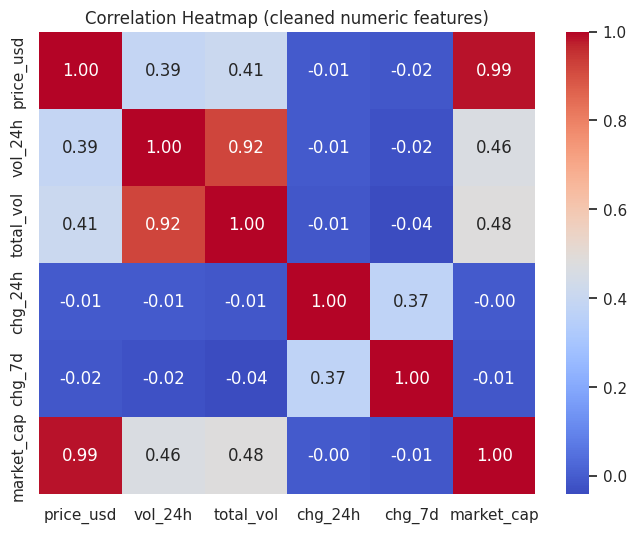

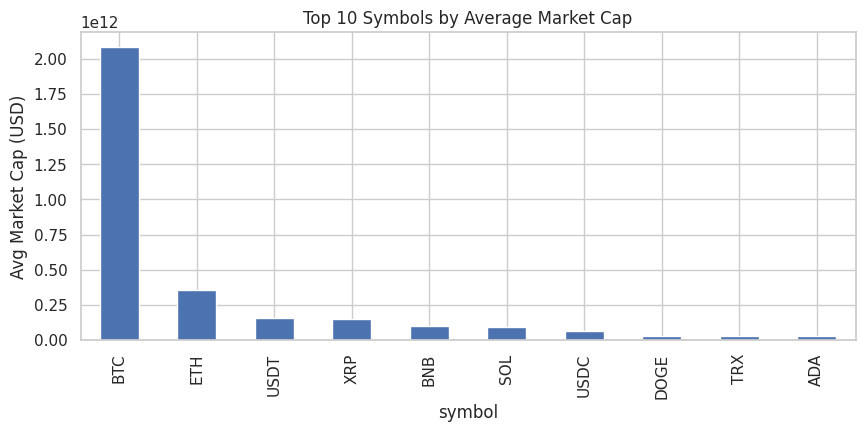

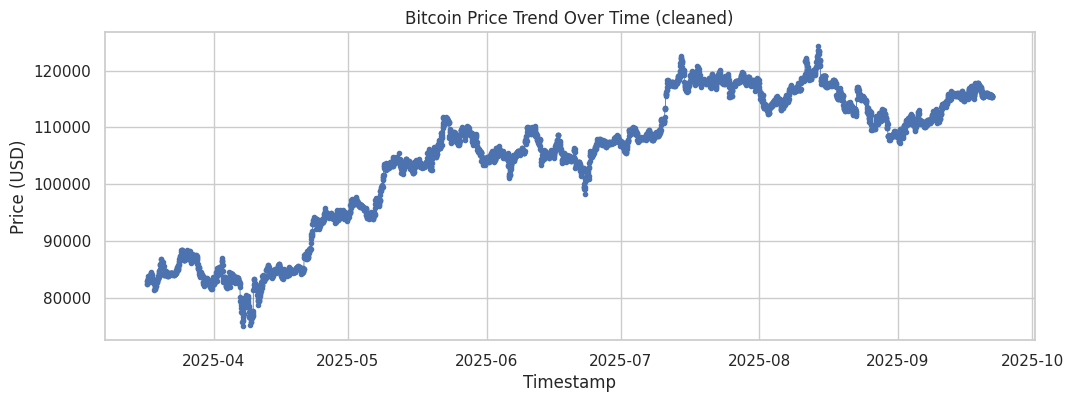

In [7]:
# 1) Correlation heatmap for numeric features
numeric_features = [c for c in cols_to_clean if c in df.columns]
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (cleaned numeric features)")
plt.show()

# 2) Top 10 cryptocurrencies by average market cap
if 'market_cap' in df.columns:
    top_by_market = df.groupby('symbol')['market_cap'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,4))
    top_by_market.plot(kind='bar')
    plt.title("Top 10 Symbols by Average Market Cap")
    plt.ylabel("Avg Market Cap (USD)")
    plt.show()

# 3) Price trend over time for Bitcoin
if 'symbol' in df.columns and 'timestamp' in df.columns and 'price_usd' in df.columns:
    btc = df[df['symbol'].str.upper() == 'BTC'].sort_values('timestamp')
    if len(btc) > 1:
        plt.figure(figsize=(12,4))
        plt.plot(btc['timestamp'], btc['price_usd'], marker='.', linewidth=0.6)
        plt.title("Bitcoin Price Trend Over Time (cleaned)")
        plt.xlabel("Timestamp")
        plt.ylabel("Price (USD)")
        plt.show()
    else:
        print("Not enough BTC rows to plot time series.")


# **STEP 7 — Statistics**

,count,mean,median,mode,min,max,range,variance,std_dev,q1,q3,iqr
feature,,,,,,,,,,,,
price_usd,93450,5.458249e+03,3.401450e+00,1.001000e+00,1.008000e-05,1.242951e+05,1.242951e+05,5.271407e+08,2.295954e+04,6.910250e-01,1.157977e+02,1.151067e+02
vol_24h,93450,1.005498e+10,8.893300e+08,1.010000e+09,1.521900e+05,2.154500e+11,2.154498e+11,5.867543e+20,2.422301e+10,3.053075e+08,4.500000e+09,4.194692e+09
total_vol,93450,7.727521e+00,7.100000e-01,0.000000e+00,0.000000e+00,8.409000e+01,8.409000e+01,2.962648e+02,1.721234e+01,2.600000e-01,3.710000e+00,3.450000e+00
chg_24h,93450,2.909583e-01,1.000000e-02,0.000000e+00,-2.524000e+01,6.946000e+01,9.470000e+01,1.354693e+01,3.680615e+00,-1.390000e+00,1.690000e+00,3.080000e+00
chg_7d,93450,2.211708e+00,3.000000e-02,0.000000e+00,-3.771000e+01,1.678900e+02,2.056000e+02,1.143596e+02,1.069390e+01,-2.850000e+00,5.590000e+00,8.440000e+00
market_cap,93450,1.591834e+11,1.918000e+10,8.300000e+09,4.510000e+06,2.460000e+12,2.459995e+12,2.057005e+23,4.535421e+11,8.900000e+09,9.137000e+10,8.247000e+10


Linear Regression: price_usd = 4.988844e-08 * market_cap + -2483.161100
R-squared: 0.9712


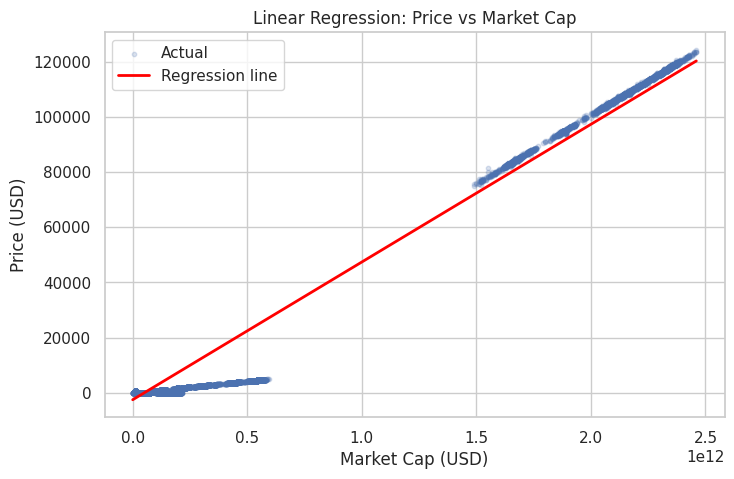

In [9]:
def series_mode(s):
    m = s.mode()
    if len(m) > 0:
        return m.iloc[0]
    else:
        return np.nan

stats_list = []
for c in numeric_features:
    col = df[c].dropna()
    if len(col) == 0:
        continue
    stats_list.append({
        'feature': c,
        'count': int(col.count()),
        'mean': float(col.mean()),
        'median': float(col.median()),
        'mode': float(series_mode(col)),
        'min': float(col.min()),
        'max': float(col.max()),
        'range': float(col.max() - col.min()),
        'variance': float(col.var()),
        'std_dev': float(col.std()),
        'q1': float(col.quantile(0.25)),
        'q3': float(col.quantile(0.75)),
        'iqr': float(col.quantile(0.75) - col.quantile(0.25))
    })

stats_df = pd.DataFrame(stats_list)
display(stats_df.set_index('feature'))

# Regression Line
if 'market_cap' in df.columns and 'price_usd' in df.columns:
    reg_df = df[(df['market_cap'] > 0) & (df['price_usd'] >= 0)].copy()
    if len(reg_df) > 10:
        X = reg_df[['market_cap']].values
        y = reg_df['price_usd'].values
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = model.score(X, y)
        coef = model.coef_[0]
        intercept = model.intercept_

        print(f"Linear Regression: price_usd = {coef:.6e} * market_cap + {intercept:.6f}")
        print(f"R-squared: {r2:.4f}")

        # Plot scatter + regression line
        idx = np.argsort(X.ravel())
        plt.figure(figsize=(8,5))
        plt.scatter(X, y, alpha=0.2, s=10, label='Actual')
        plt.plot(X.ravel()[idx], y_pred[idx], color='red', linewidth=2, label='Regression line')
        plt.xlabel("Market Cap (USD)")
        plt.ylabel("Price (USD)")
        plt.title("Linear Regression: Price vs Market Cap")
        plt.legend()
        plt.show()
    else:
        print("Not enough points for robust regression.")
else:
    print("market_cap or price_usd missing; cannot run regression.")


# **STEP 8 — Outliers using Boxplot**

Price outliers detected: 18119 rows (lower bound -171.97, upper bound 288.46)


,timestamp,name,symbol,price_usd,vol_24h,total_vol,chg_24h,chg_7d,market_cap,price_usd_raw,vol_24h_raw,total_vol_raw,chg_24h_raw,chg_7d_raw,market_cap_raw
1,2025-09-22 01:35:11,Ethereum,ETH,4457.47,1.718000e+10,17.94,-0.70,-3.43,5.386500e+11,"4,457.47",$17.18B,17.94%,-0.70%,-3.43%,$538.65B
3,2025-09-22 01:35:11,Bitcoin,BTC,115322.10,2.149000e+10,22.11,-0.43,-0.51,2.300000e+12,"115,322.10",$21.49B,22.11%,-0.43%,-0.51%,$2.30T
5,2025-09-22 01:35:11,BNB,BNB,1051.10,4.390000e+09,4.43,1.10,12.45,1.460700e+11,"1,051.10",$4.39B,4.43%,+1.10%,+12.45%,$146.07B
12,2025-09-22 01:05:11,Bitcoin Cash,BCH,596.96,2.716600e+08,0.29,-0.19,0.32,1.189000e+10,596.96,$271.66M,0.29%,-0.19%,+0.32%,$11.89B
21,2025-09-22 01:05:11,Ethereum,ETH,4472.68,1.852000e+10,17.94,-0.46,-3.19,5.404800e+11,"4,472.68",$18.52B,17.94%,-0.46%,-3.19%,$540.48B
23,2025-09-22 01:05:11,Bitcoin,BTC,115446.40,2.242000e+10,22.11,-0.49,-0.56,2.300000e+12,"115,446.40",$22.42B,22.11%,-0.49%,-0.56%,$2.30T
25,2025-09-22 01:05:11,BNB,BNB,1050.80,4.520000e+09,4.43,2.13,12.56,1.459900e+11,"1,050.80",$4.52B,4.43%,+2.13%,+12.56%,$145.99B
32,2025-09-22 00:35:11,Bitcoin Cash,BCH,595.72,2.749600e+08,0.29,-0.18,0.30,1.188000e+10,595.72,$274.96M,0.29%,-0.18%,+0.30%,$11.88B
41,2025-09-22 00:35:11,BNB,BNB,1045.90,4.540000e+09,4.43,2.39,12.55,1.456600e+11,"1,045.90",$4.54B,4.43%,+2.39%,+12.55%,$145.66B
44,2025-09-22 00:35:11,Bitcoin,BTC,115262.70,2.170000e+10,22.11,-0.44,-0.48,2.300000e+12,"115,262.70",$21.70B,22.11%,-0.44%,-0.48%,$2.30T


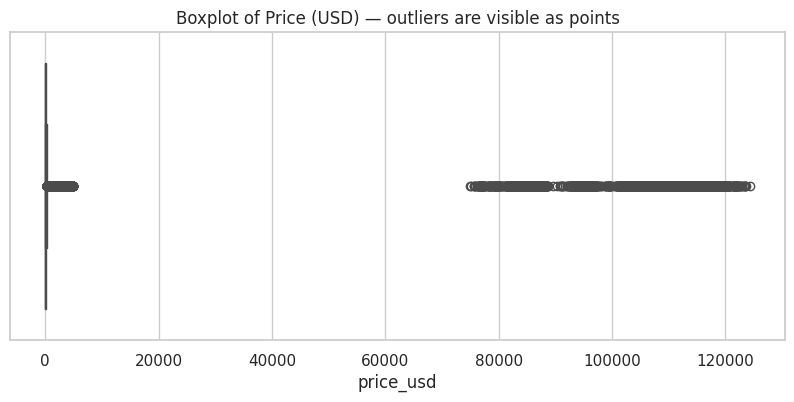

In [10]:
if 'price_usd' in df.columns:
    s = df['price_usd'].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df['price_usd'] < lower) | (df['price_usd'] > upper)]
    print(f"Price outliers detected: {len(outliers)} rows (lower bound {lower:.2f}, upper bound {upper:.2f})")
    display(outliers.head(10))

    # Boxplot visualization
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df['price_usd'])
    plt.title("Boxplot of Price (USD) — outliers are visible as points")
    plt.show()
else:
    print("price_usd not present for outlier detection.")


In [11]:
df.to_excel("cleaned_crypto.xlsx", index=False)
files.download("cleaned_crypto.xlsx")

print("\nCleaned dataset saved as cleaned_crypto.xlsx")
print("Final Shape:", df.shape)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Cleaned dataset saved as cleaned_crypto.xlsx
Final Shape: (93450, 15)
